In [24]:
import pandas as pd

In [25]:
product_df = pd.read_csv("/workspaces/hi/ProductLevel.csv", encoding="latin1")
stage_df = pd.read_csv("/workspaces/hi/Stage Level Data.csv", encoding="latin1")

In [26]:
print(f"Product Dataset:  {product_df.shape}")
print(f"Stage Dataset:    {stage_df.shape}")

Product Dataset:  (866, 25)
Stage Dataset:    (1764, 7)


In [27]:
product_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   *PCF-ID                                    866 non-null    str    
 1   Year of reporting                          866 non-null    int64  
 2   *Stage-level CO2e available                866 non-null    str    
 3   Product name (and functional unit)         866 non-null    str    
 4   Product detail                             856 non-null    str    
 5   Company                                    866 non-null    str    
 6   Country (where company is incorporated)    866 non-null    str    
 7   Company's GICS Industry Group              866 non-null    str    
 8   Company's GICS Industry                    866 non-null    str    
 9   *Company's sector                          866 non-null    str    
 10  Product weight (kg)                  

In [28]:
stage_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1764 entries, 0 to 1763
Data columns (total 7 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   *PCF-ID                                             1764 non-null   str    
 1   Description of LCA stage                            1764 non-null   str    
 2   Scope-characterization of LCA stage                 1764 non-null   str    
 3   *Assigned value chain portion                       1764 non-null   str    
 4   Emissions at stage (kg CO2e)                        1764 non-null   float64
 5   *Emissions at this stage are exclusively transport  1764 non-null   str    
 6   *Emissions at this stage are exclusively EndOfLife  1764 non-null   str    
dtypes: float64(1), str(6)
memory usage: 96.6 KB


In [29]:
import pandas as pd


product_data_summary = pd.DataFrame({
    'Source_Table': 'product_df',
    'Column_Name': product_df.columns,
    'Non_Null_Count': product_df.notnull().sum().values,
    'Unique_Values': product_df.nunique().values,
    'Data_Type': product_df.dtypes.values
})


stage_data_summary = pd.DataFrame({
    'Source_Table': 'stage_df',
    'Column_Name': stage_df.columns,
    'Non_Null_Count': stage_df.notnull().sum().values,
    'Unique_Values': stage_df.nunique().values,
    'Data_Type': stage_df.dtypes.values
})

key_summary_data = pd.concat([product_data_summary, stage_data_summary], ignore_index=True)



display(key_summary_data)

,Source_Table,Column_Name,Non_Null_Count,Unique_Values,Data_Type
0,product_df,*PCF-ID,866,866,str
1,product_df,Year of reporting,866,5,int64
2,product_df,*Stage-level CO2e available,866,2,str
3,product_df,Product name (and functional unit),866,672,str
4,product_df,Product detail,856,496,str
5,product_df,Company,866,145,str
6,product_df,Country (where company is incorporated),866,28,str
7,product_df,Company's GICS Industry Group,866,30,str
8,product_df,Company's GICS Industry,866,35,str
9,product_df,*Company's sector,866,8,str


In [30]:
product_df['Year of reporting'].value_counts().sort_index()

Year of reporting
2013    179
2014    190
2015    217
2016    218
2017     62
Name: count, dtype: int64

The dataset spans 5 continuous reporting years (2013–2017) with no missing values. Rather than treating year as an unordered categorical or raw large integer, we transform it into a relative temporal trend index ($\text{Year} - 2012 \in [1, 5]$). This captures progressive grid decarbonization and evolving carbon accounting standards over time in a format that tree-based models can split on logically.

<span style="color:red;">Year_Index তৈরি করা হচ্ছে (1 to 5)
 ```
 product_df['Year_Index'] = product_df['Year of reporting'] - 2012
```

</span>

In [31]:
product_df['*Stage-level CO2e available'].value_counts()

*Stage-level CO2e available
No     445
Yes    421
Name: count, dtype: int64

In [32]:
product_df['Country (where company is incorporated)'].value_counts()

Country (where company is incorporated)
USA               305
Japan             110
Germany            67
Taiwan             60
Finland            35
Netherlands        35
United Kingdom     32
Switzerland        28
Sweden             26
Italy              23
South Korea        22
France             20
Brazil             17
India              16
Spain              13
South Africa       11
Belgium             8
China               6
Canada              6
Ireland             6
Australia           6
Malaysia            4
Chile               3
Colombia            2
Luxembourg          2
Lithuania           1
Indonesia           1
Greece              1
Name: count, dtype: int64

### Drop replace by Region

In [20]:
product_df["Company's GICS Industry Group"].value_counts()

Company's GICS Industry Group
Technology Hardware & Equipment                                         195
Materials                                                               161
Food, Beverage & Tobacco                                                101
Automobiles & Components                                                 73
Consumer Durables & Apparel                                              52
Commercial & Professional Services                                       42
Capital Goods                                                            33
Chemicals                                                                29
Software & Services                                                      27
Food & Staples Retailing                                                 24
Textiles, Apparel, Footwear and Luxury Goods                             16
Media                                                                    15
Food & Beverage Processing                                

In [22]:
product_df["Company's GICS Industry"].value_counts()

Company's GICS Industry
Not used for 2015 reporting                       215
Chemicals                                          82
Computers & Peripherals                            70
Beverages                                          70
Electronic Equipment, Instruments & Components     47
Commercial Services & Supplies                     42
Auto Components                                    38
Paper & Forest Products                            34
Textiles, Apparel & Luxury Goods                   31
Food Products                                      30
Containers & Packaging                             28
Office Electronics                                 24
Household Durables                                 21
Metals & Mining                                    16
Software                                           14
Electrical Equipment                               14
Food & Staples Retailing                           14
Automobiles                                        13
Medi

"Provides reliable granular industry classification (30 well-defined groups) without structural missingness. Captures mid-level manufacturing and operational carbon baselines."

In [23]:
product_df["*Company's sector"].value_counts()

*Company's sector
Computer, IT & telecom                  253
Food & Beverage                         139
Home durables, textiles, & equipment    122
Chemicals                               116
Automobiles & components                 75
Construction & commercial materials      67
Comm. equipm. & capital goods            56
Packaging for consumer goods             38
Name: count, dtype: int64

Highly dense, zero-missingness high-level economic categorization (8 primary sectors). Serves as an ideal top-tier categorical driver for baseline PCF differentiation.

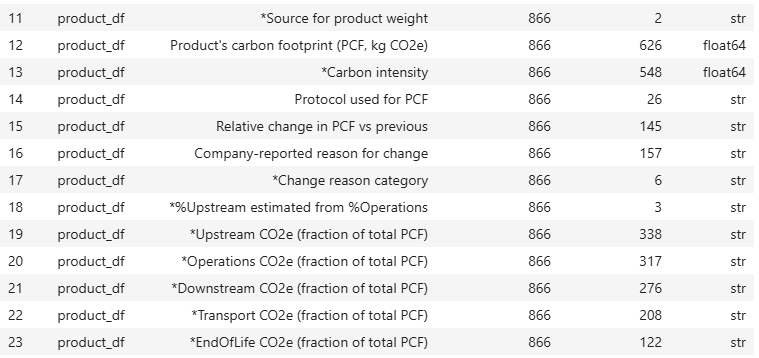

In [36]:
product_df['Protocol used for PCF'].value_counts()

Protocol used for PCF
ISO                            353
GHGP                           183
Not reported                   179
PAS2050                         73
TRACI 2.1                       20
Paper Profile                   12
MIT PAIA                         9
ILCD Handbook                    8
M. Env. Japan                    4
EcoLeaf                          4
Japan CFP                        2
EICC Tool                        2
EUPEF                            2
CEPI                             2
Carbon Labeling Certificate      2
WBCSD                            1
French PEF                       1
FEFCO                            1
Traci 2.1                        1
JRM Assoc.                       1
Korea CL Guide                   1
JEC/BIOGRACE                     1
CFP Japan                        1
EPD                              1
Bilan Carbone                    1
M. Env. Japan v2.2               1
Name: count, dtype: int64

In [37]:
product_df['*Change reason category'].value_counts()

*Change reason category
N/a (no %change reported)                                 482
Product carbon efficiency changed                         166
N/a (no previous data available)                          134
No specific reason reported                                38
Model and/or parameters changed (but not product)          25
Model/parameters AND product carbon efficiency changed     21
Name: count, dtype: int64

"Dropped (*Change reason category): Over 75.5% of the records contain non-informative or missing entries (N/a (no %change reported), N/a (no previous data available), and No specific reason reported). Furthermore, this feature represents post-facto explanatory commentary regarding year-over-year PCF variance rather than an inherent physical or manufacturing property of the product itself."

In [38]:
product_df['*%Upstream estimated from %Operations'].value_counts()

*%Upstream estimated from %Operations
N/a (product with insufficient stage-level data)    445
No                                                  317
Yes                                                 104
Name: count, dtype: int64

"Dropped (*%Upstream estimated from %Operations): Over 51.4% of the dataset contains missing or uninformative values (N/a (product with insufficient stage-level data)). Additionally, this feature represents an estimation flag used during data compilation rather than an intrinsic physical or supply-chain attribute of the product. Structural stage availability is already captured via engineered LCA stage metadata."

### Stage Level Dataset

In [39]:
stage_df['Scope-characterization of LCA stage'].value_counts()

Scope-characterization of LCA stage
Scope 3                                           662
N/a (field not yet included in 2013 reporting)    509
Scope 1, 2, & 3                                   220
Scope 1 & 2                                       161
Scope 1                                           100
Scope 2                                            91
BLANK                                              15
Other: Scope 1 & 3                                  6
Name: count, dtype: int64

In [ ]:
# float টাইপকে int টাইপে কনভার্ট করা (5.0 -> 5)

cols_to_int = ['total_lca_stages', 'has_transport_stage', 'has_endoflife_stage']

In [44]:
# Grouping stage_df to create product-level binary features
stage_features = stage_df.groupby('*PCF-ID').agg(
    # কলাম ৩০: Transport stage আছে কি না (1 / 0)
    has_transport_stage=(
        '*Emissions at this stage are exclusively transport', 
        lambda x: int((x == 'Yes').any())
    ),
    # কলাম ৩১: End of Life stage আছে কি না (1 / 0)
    has_endoflife_stage=(
        '*Emissions at this stage are exclusively EndOfLife', 
        lambda x: int((x == 'Yes').any())
    )
).reset_index()

# product_df-এর সাথে Merge করা
clean_df = pd.merge(product_df, stage_features, on='*PCF-ID', how='left')

# যাদের stage_df-এ তথ্য ছিল না তাদের 0 ধরা
clean_df['has_transport_stage'] = clean_df['has_transport_stage'].fillna(0).astype(int)
clean_df['has_endoflife_stage'] = clean_df['has_endoflife_stage'].fillna(0).astype(int)

In [ ]:
clean_df['has_transport_stage']

,*PCF-ID,Year of reporting,*Stage-level CO2e available,Product name (and functional unit),Product detail,Company,Country (where company is incorporated),Company's GICS Industry Group,Company's GICS Industry,*Company's sector,...,*Change reason category,*%Upstream estimated from %Operations,*Upstream CO2e (fraction of total PCF),*Operations CO2e (fraction of total PCF),*Downstream CO2e (fraction of total PCF),*Transport CO2e (fraction of total PCF),*EndOfLife CO2e (fraction of total PCF),*Adjustments to raw data (if any),has_transport_stage,has_endoflife_stage
0,10056-1-2014,2014,Yes,Frosted Flakes(R) Cereal,"Frosted Flakes(R), 23 oz., Produced in Lancast...",Kellogg Company,USA,"Food, Beverage & Tobacco",Food Products,Food & Beverage,...,N/a (no %change reported),No,57.50%,30.00%,12.50%,4.50%,(included in downstream but not reported separ...,Divided stage and total emissions by 1000 (bas...,1,0
1,10056-1-2015,2015,Yes,"Frosted Flakes, 23 oz, produced in Lancaster, ...",Cereal,Kellogg Company,USA,Food & Beverage Processing,Not used for 2015 reporting,Food & Beverage,...,N/a (no %change reported),No,57.50%,30.00%,12.50%,4.50%,(included in downstream but not reported separ...,Divided stage and total emissions by 1000 (bas...,1,0
2,10222-1-2013,2013,Yes,Office Chair,Field not included in 2013 data,KNOLL INC,USA,Capital Goods,Building Products,Comm. equipm. & capital goods,...,N/a (no previous data available),Yes,80.63%,17.36%,2.01%,(included in up/downstream but not reported se...,0.00%,"Changed %change to zero, according to field ""c...",0,1
3,10261-1-2017,2017,Yes,Multifunction Printers,bizhub C458,"Konica Minolta, Inc.",Japan,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components","Computer, IT & telecom",...,N/a (no previous data available),No,30.65%,5.51%,63.84%,1.01%,2.76%,NaN,1,1
4,10261-2-2017,2017,Yes,Multifunction Printers,bizhub C558,"Konica Minolta, Inc.",Japan,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components","Computer, IT & telecom",...,N/a (no previous data available),No,25.08%,4.51%,70.41%,0.83%,2.26%,NaN,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
861,9298-2-2014,2014,Yes,Desktop CPU,Microprocessors made for desktop PCs,Intel Corporation,USA,Semiconductors & Semiconductor Equipment,Semiconductors & Semiconductor Equipment,"Computer, IT & telecom",...,N/a (no %change reported),No,32.14%,54.29%,13.57%,(included in up/downstream but not reported se...,(included in downstream but not reported separ...,NaN,0,0
862,9298-3-2013,2013,Yes,Mobile CPU,Field not included in 2013 data,Intel Corporation,USA,Technology Hardware & Equipment,Computers & Peripherals,"Computer, IT & telecom",...,Product carbon efficiency changed,No,28.57%,71.43%,0.00%,0.00%,(included in downstream but not reported separ...,NaN,1,0
863,9298-3-2014,2014,Yes,Mobile CPU,Microprocessors made for laptop and mobile com...,Intel Corporation,USA,Semiconductors & Semiconductor Equipment,Semiconductors & Semiconductor Equipment,"Computer, IT & telecom",...,N/a (no %change reported),No,31.43%,54.29%,14.29%,(included in up/downstream but not reported se...,(included in downstream but not reported separ...,NaN,0,0
864,9792-1-2017,2017,No,Complete catalyst system for diesel-powered pa...,3 different coated substrates (uncanned) for u...,Johnson Matthey,United Kingdom,Materials,Chemicals,Chemicals,...,N/a (no %change reported),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),N/a (product with insufficient stage-level data),NaN,0,0


In [47]:
clean_df['has_transport_stage'].value_counts()

has_transport_stage
0    568
1    298
Name: count, dtype: int64

In [48]:
clean_df['has_endoflife_stage'].value_counts()

has_endoflife_stage
0    676
1    190
Name: count, dtype: int64